In [61]:

from mGST.low_level_jit import contract_mps_all_povm, cost_function_jax_mps
from mGST.additional_fns import perturbed_target_init, sampled_measurements, random_seq_design

from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output, get_compressed_rep_mgst_cholesky, create_2q_emerald_gst_config

from mGST.trust_region import run_riemannian_optimization
from mGST.typing import TrustRegionOptions, GradientDescentOptions
from mGST.visualization import plot_cost_function, plot_alternating_optimization
import jax.numpy as jnp
import numpy as np
import pickle

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

In [2]:
Q2_GST_EMERALD = create_2q_emerald_gst_config()

with open(data_path +'emerald_2q_parallel_qubits_44__48.pkl', 'rb') as function:
    data = pickle.load(function)
    
X_true = data["X_true"]
E_true = data["E_true"]
rho_true = data["rho_true"]

K_target = data["K_target"]
X_target = data["X_target"]
E_target = data["E_target"]
rho_target = data["rho_target"]

# dimensions
dim = rho_true.shape[0]
num_povm = E_true.shape[0]
num_gates = X_true.shape[0]
bsize = 30 * dim
# Getting the values to be initialized
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(X_target, E_target, rho_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = rho_target.reshape(dim, dim)
povm_target_matrices = E_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, X_target)

INFO:2025-09-30 13:35:57,011:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-09-30 13:35:57,011 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-09-30 13:35:57,013:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [3]:
state_mgst_true = rho_true.reshape(-1)
povm_mgst_true = E_true.reshape(num_povm, -1)

kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true  = get_compressed_rep_from_mgst_output(X_true, povm_mgst_true, state_mgst_true, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax = povm_psd_2q_true.conj().transpose(0, 2, 1) @ povm_psd_2q_true
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_true, kraus_tensor_2q_true.conj()).reshape((num_gates, dim**2, dim**2))

target_operators = [kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target]

jnp.allclose(state_psd_2q_true @ state_psd_2q_true.conj().T, rho_true), jnp.allclose(povm_jax, E_true), jnp.allclose(superop_kraus_test, X_true)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

In [4]:
shots = 1000

N = 100  # Number of sequences
N_short = int(jnp.ceil(N / 2))
N_long = int(jnp.floor(N / 2))
meas_samples = 1e5  # Number of samples per sequences

# generate random numbers between 0 and $d^l - 1$
J = random_seq_design(num_gates, 1, 8, 14, N_short, N_long)
indices_list_2q = [indices[indices != -1] for indices in J]
# compute outcome probabilities
prob_matrix_exact = []
for indices in indices_list_2q:
    prob_matrix_exact.append(jnp.real(contract_mps_all_povm(kraus_tensor_2q_true, povm_psd_2q_true, state_psd_2q_true, indices)))
    
prob_matrix_exact = jnp.array(prob_matrix_exact).T
prob_matrix_2q_sampled = sampled_measurements(prob_matrix_exact, shots, seed=42)

In [ ]:
kraus_rank = dim**2
kraus_init_mgst = perturbed_target_init(X_target, kraus_rank, seed=42)
x_init_mgst = jnp.einsum("ijkl,ijnm -> iknlm", kraus_init_mgst, kraus_init_mgst.conj()).reshape((num_gates, dim**2, dim**2))
povm_target_mgst = E_target.reshape(num_povm, -1)
rho_target_mgst = rho_target.reshape(-1)
init_mgst = [kraus_init_mgst, povm_target_mgst, rho_target_mgst]

povm_psd_init_jax, state_psd_init_jax = get_compressed_rep_mgst_cholesky(povm_target_mgst, rho_target_mgst)
kraus_tensor_init_jax = jnp.array(kraus_init_mgst)

povm_psd_init_mgst = np.array(povm_psd_init_jax)
state_psd_init_mgst = np.array(state_psd_init_jax)


# Optimization

In [ ]:
init_operators_jax = {
    "kraus_tensor_init": kraus_tensor_init_jax,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

cost_fn_kwargs = {
    "indices_list": indices_list_2q,
    "prob_matrix": prob_matrix_2q_sampled,
    "jit": True,
}

optimization_options = {
    "kraus": TrustRegionOptions(),
    "povm": TrustRegionOptions(),
    "state": TrustRegionOptions(),
}

print(optimization_options)
initial_cost_value = cost_function_jax_mps(
    kraus_tensor=kraus_tensor_init_jax,
    povm_psd=povm_psd_init_jax,
    state_psd=state_psd_init_jax,
    **cost_fn_kwargs,
)
print(f"initial_cost: {initial_cost_value}")

{'kraus': TrustRegionOptions(num_iterations=20, metric='euclidean', verbose=False, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=None, kappa_cg=None, verbose_cg=False), 'povm': TrustRegionOptions(num_iterations=20, metric='euclidean', verbose=False, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=None, kappa_cg=None, verbose_cg=False), 'state': TrustRegionOptions(num_iterations=20, metric='euclidean', verbose=False, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-06, num_iterations_cg=10, theta_cg=None, kappa_cg=None, verbose_cg=False)}
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 7 the new count changed to: 3
at iteration 13 the new count changed to: 4
at iteration 19 the new count changed to: 5
at iteration 25 the new count changed to: 6
at iteration 31 the new count changed to: 7
at iteration 37 the new

In [11]:
optimized_operators_all_tr, cost_fn_history_all_tr = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=5,
    optimization_options=optimization_options,
    verbose=True,
)

🚀 Starting Riemannian Optimization 🚀 
 with optimization config : kraus: TrustRegionOptions
povm: TrustRegionOptions
state: TrustRegionOptions 🚀
TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 20. f(x): 2.809446e-03. |r∇f(x)|: 1.054471e-05. Radius: 8.00e-01. Rejections: 17
TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 20. f(x): 9.168032e-05. |r∇f(x)|: 5.468865e-05. Radius: 2.00e-01. Rejections: 2
TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 1. f(x): 9.130943e-05. |r∇f(x)|: 4.107342e-07. Radius: 2.00e-01. Rejections: 0
🏁 Iteration: 0/5. f(x): 9.130943e-05.
TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 1. f(x): 9.078280e-05. |r∇f(x)|: 8.938995e-07. Radius: 2.00e-01. Rejections: 0
TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 20. f(x): 8.827926e-05. |r∇f(x)|: 2.300458e-05. Radius: 1.00e-01. Rejections: 0
TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 1. f(x): 8.8

In [46]:
optimization_options_kraus_gds = {
    "povm": TrustRegionOptions(),
    "kraus": GradientDescentOptions(),
    "state": TrustRegionOptions(),
}

In [58]:
optimized_operators_kraus_gds, cost_fn_history_kraus_gds = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=10,
    optimization_options=optimization_options_kraus_gds,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization config: 
povm: TrustRegionOptions
kraus: GradientDescentOptions
state: TrustRegionOptions
TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 20. f(x): 2.809446e-03. |r∇f(x)|: 1.054471e-05. Radius: 8.00e-01. Rejections: 17
Using JAX power
TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 2. f(x): 2.118054e-03. |r∇f(x)|: 9.354091e-07. Radius: 4.00e-01. Rejections: 0
🏁 Iteration: 1/10. f(x): 2.118054e-03.
TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 20. f(x): 4.555357e-04. |r∇f(x)|: 1.868760e-04. Radius: 1.00e-01. Rejections: 4
Using JAX power
TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 2. f(x): 3.576971e-04. |r∇f(x)|: 3.427530e-07. Radius: 4.00e-01. Rejections: 0
🏁 Iteration: 2/10. f(x): 3.576971e-04.
TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 20. f(x): 3.126365e-04. |r∇f(x)|: 1.936191e-06. Radius: 2.50e-02. Rejections: 5
Using J

In [65]:
optimization_options_all_gds = {
    "povm": GradientDescentOptions(),
    "kraus": GradientDescentOptions(),
    "state": GradientDescentOptions(),
}

In [66]:
optimized_operators_all_gds, cost_fn_history_all_gds = run_riemannian_optimization(
    **init_operators_jax,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=10,
    optimization_options=optimization_options_all_gds,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 with optimization config: 
povm: GradientDescentOptions
kraus: GradientDescentOptions
state: GradientDescentOptions
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 1/10. f(x): 2.127140e-03.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 2/10. f(x): 1.772030e-03.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 3/10. f(x): 1.355020e-03.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iteration: 4/10. f(x): 1.119602e-03.
GDS started for operator: povm 🚀.
GDS started for operator: kraus 🚀.
Using JAX power
GDS started for operator: state 🚀.
Using JAX power
🏁 Iterati

# Visualization:

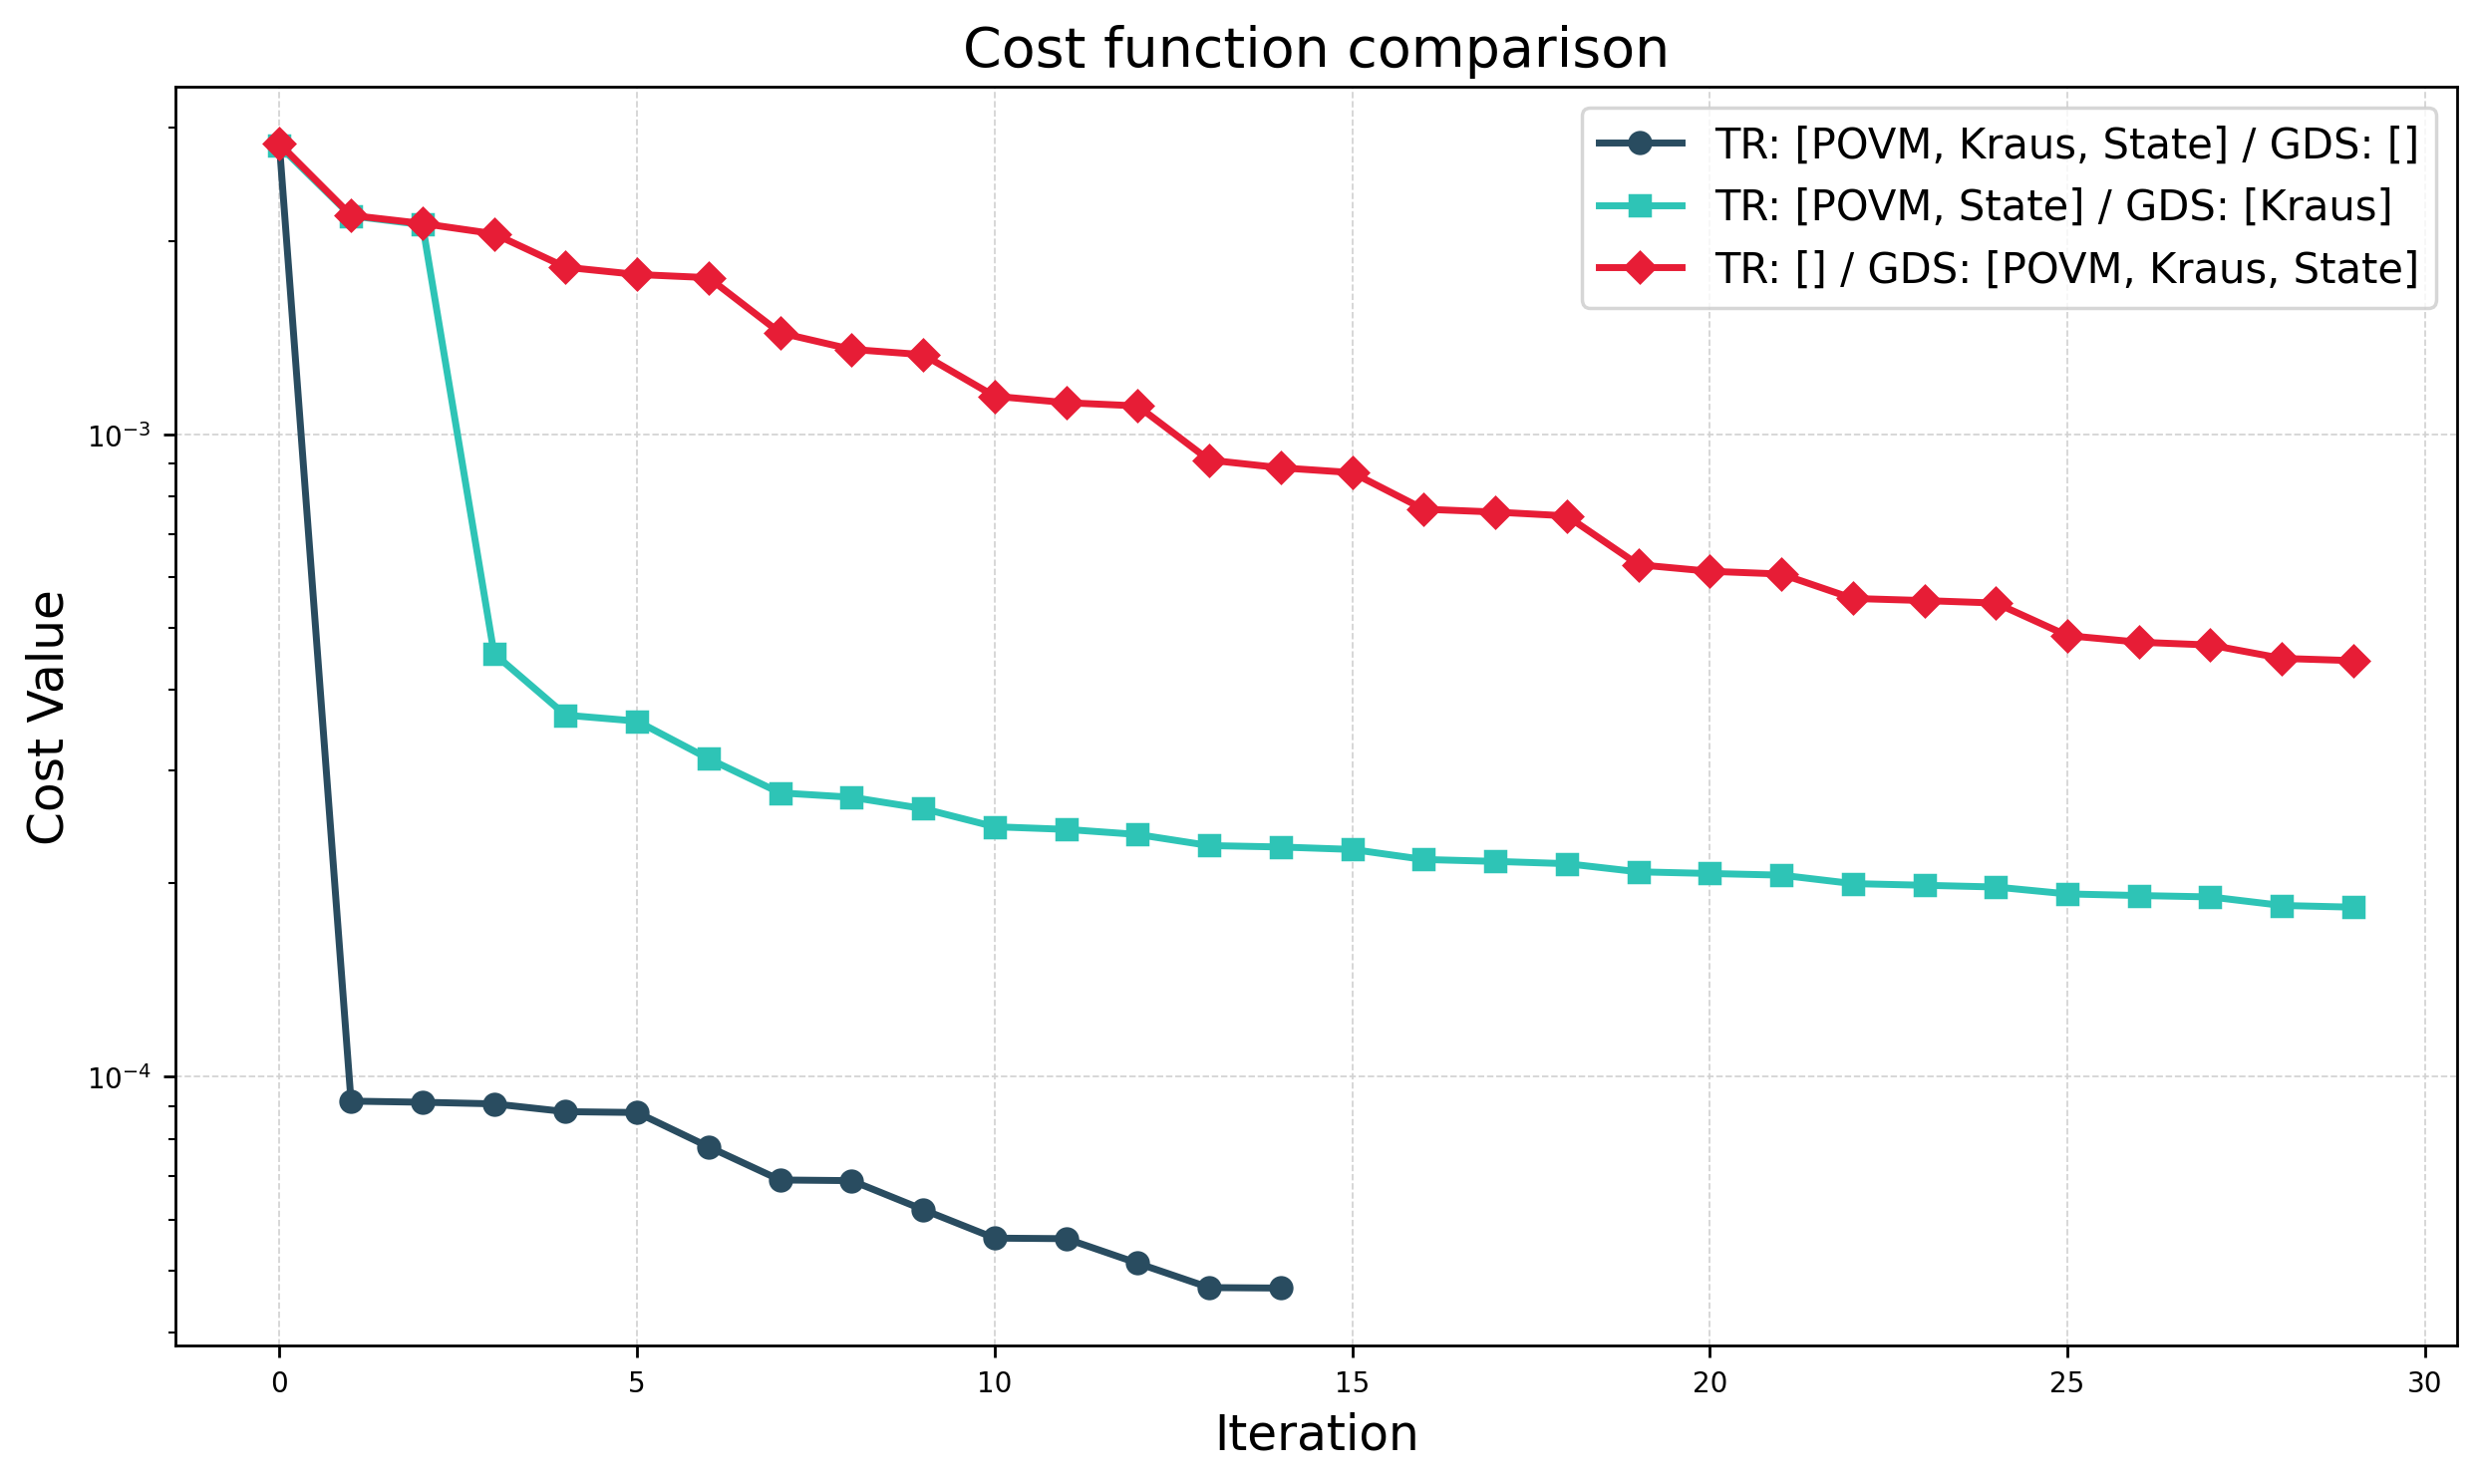

In [67]:
cost_fn_comparison = [cost_fn_history_all_tr, cost_fn_history_kraus_gds, cost_fn_history_all_gds]
labels = ["TR: [POVM, Kraus, State] / GDS: []", "TR: [POVM, State] / GDS: [Kraus]", "TR: [] / GDS: [POVM, Kraus, State]"]
plot_cost_function(cost_fn_comparison, title="Cost function comparison", labels=labels)

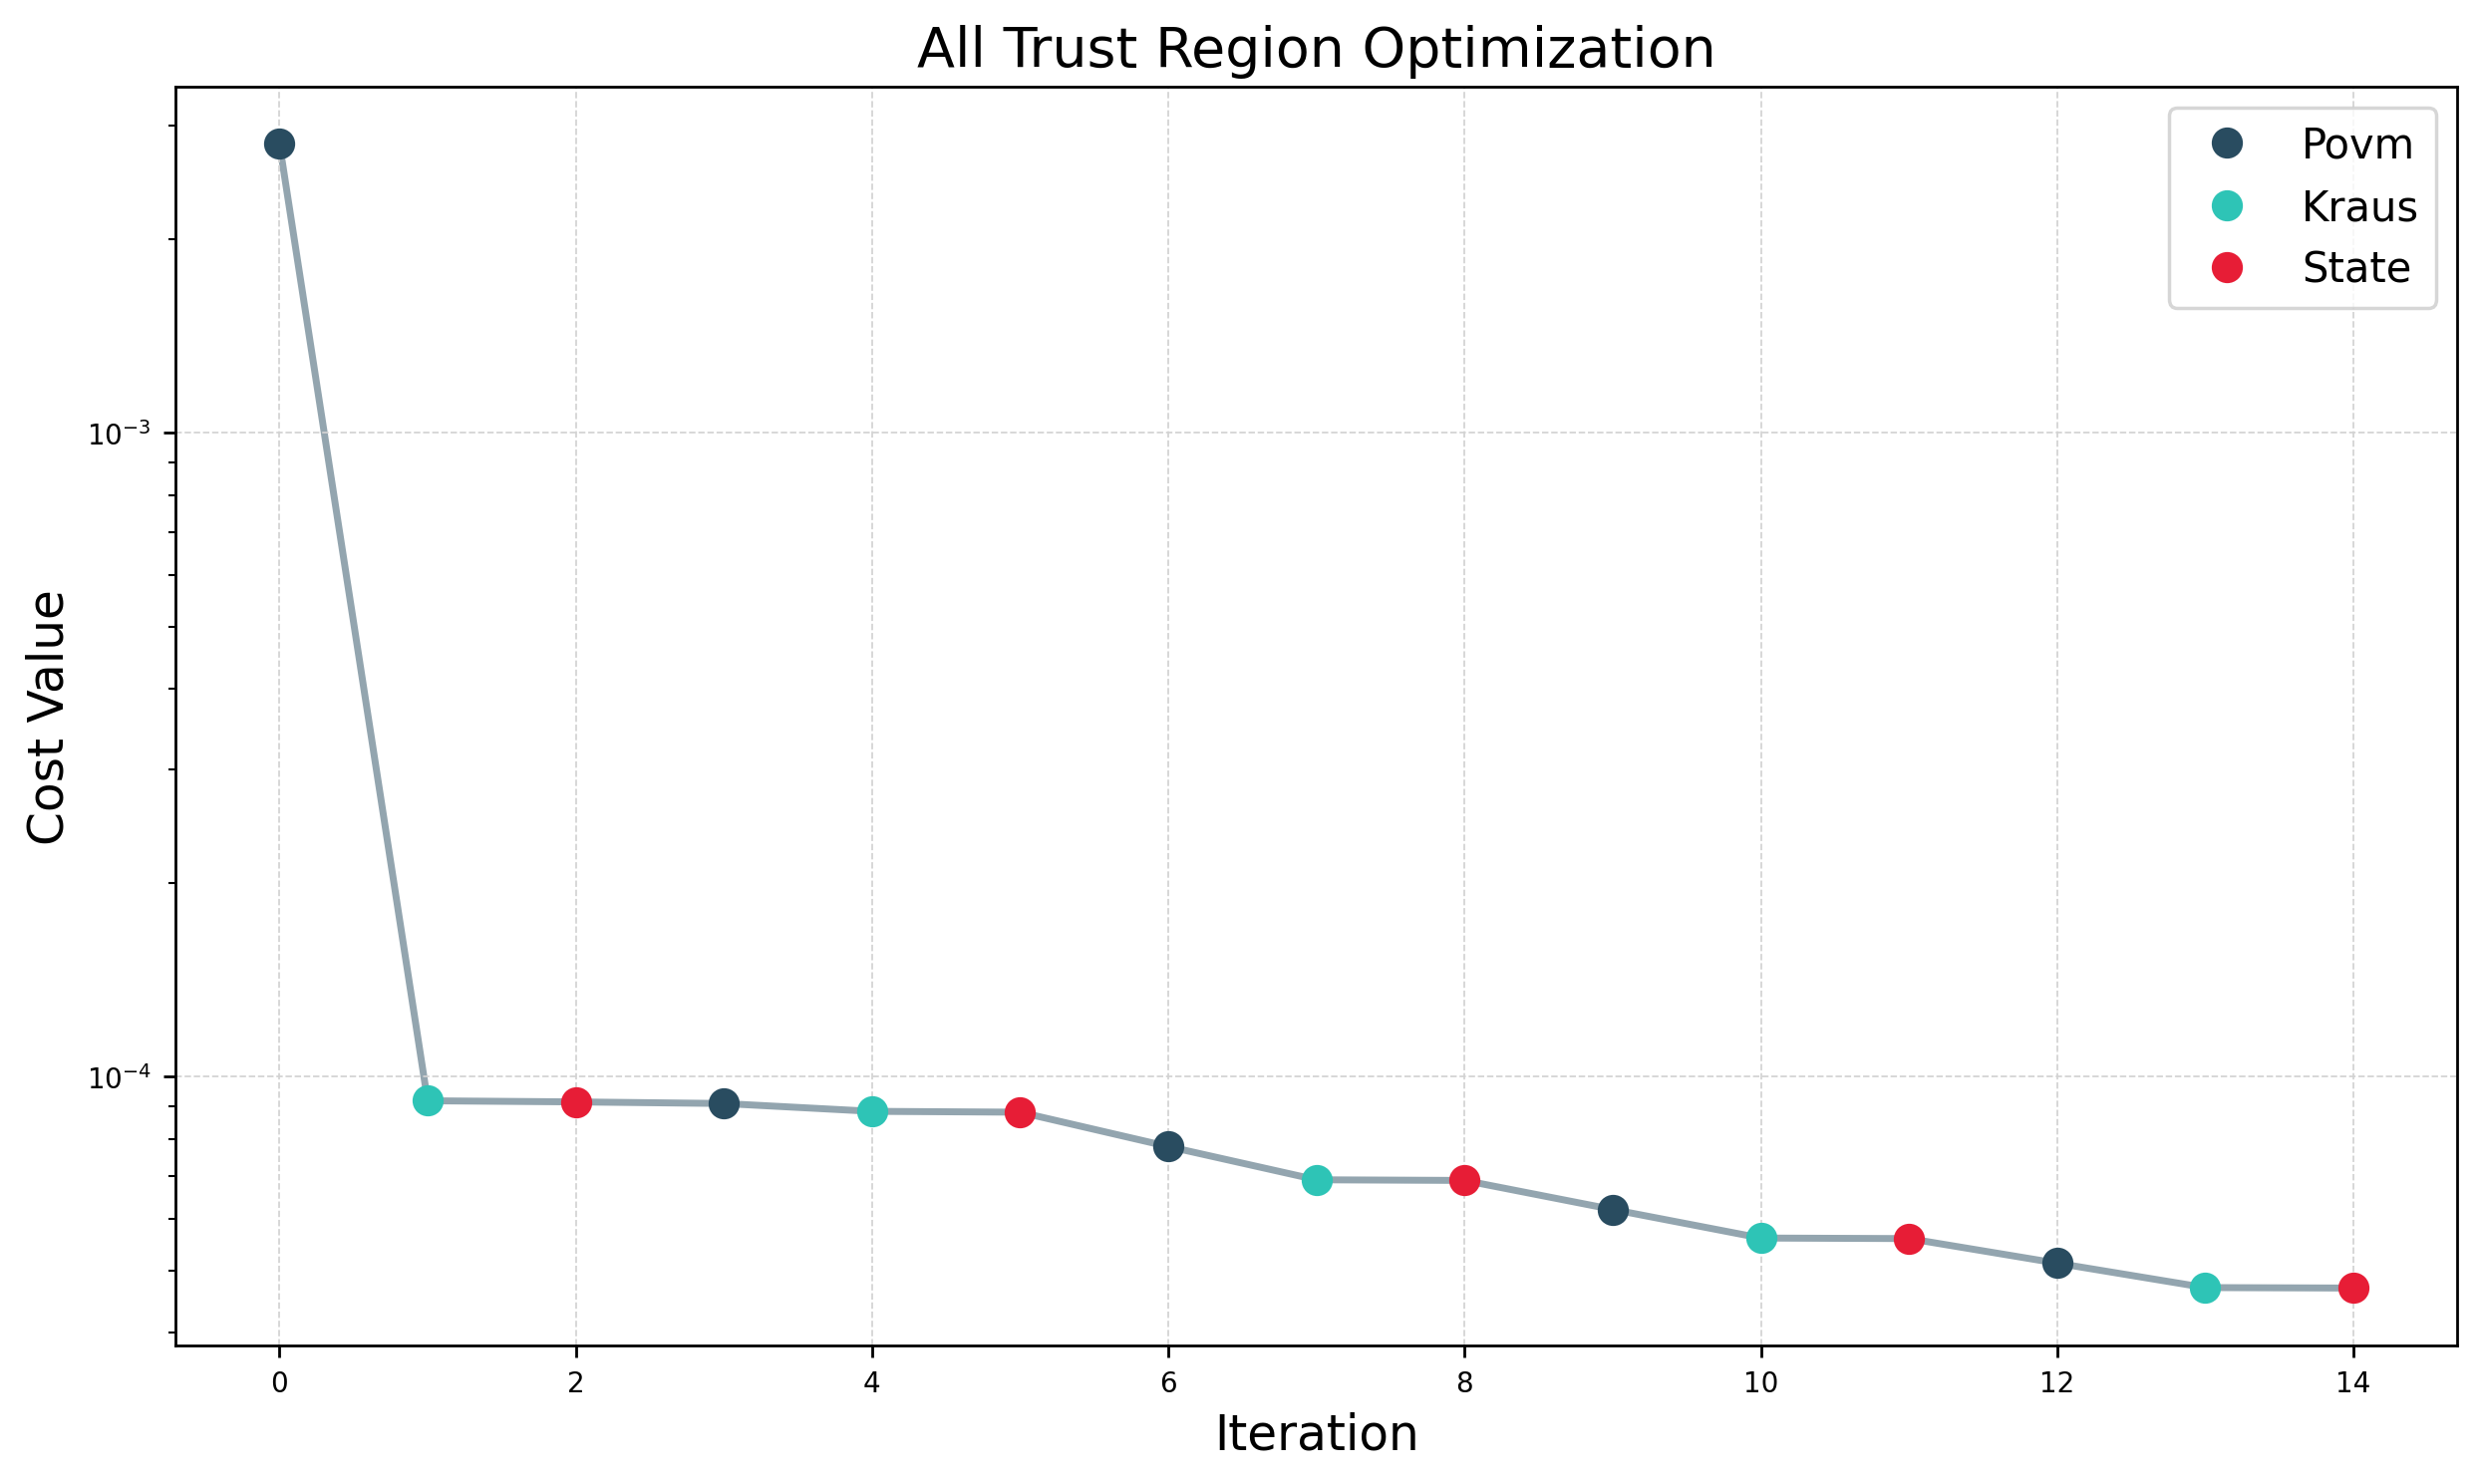

In [62]:
plot_alternating_optimization(cost_fn_history_all_tr, title="All Trust Region Optimization", operator_order=["POVM", "kraus", "state"])

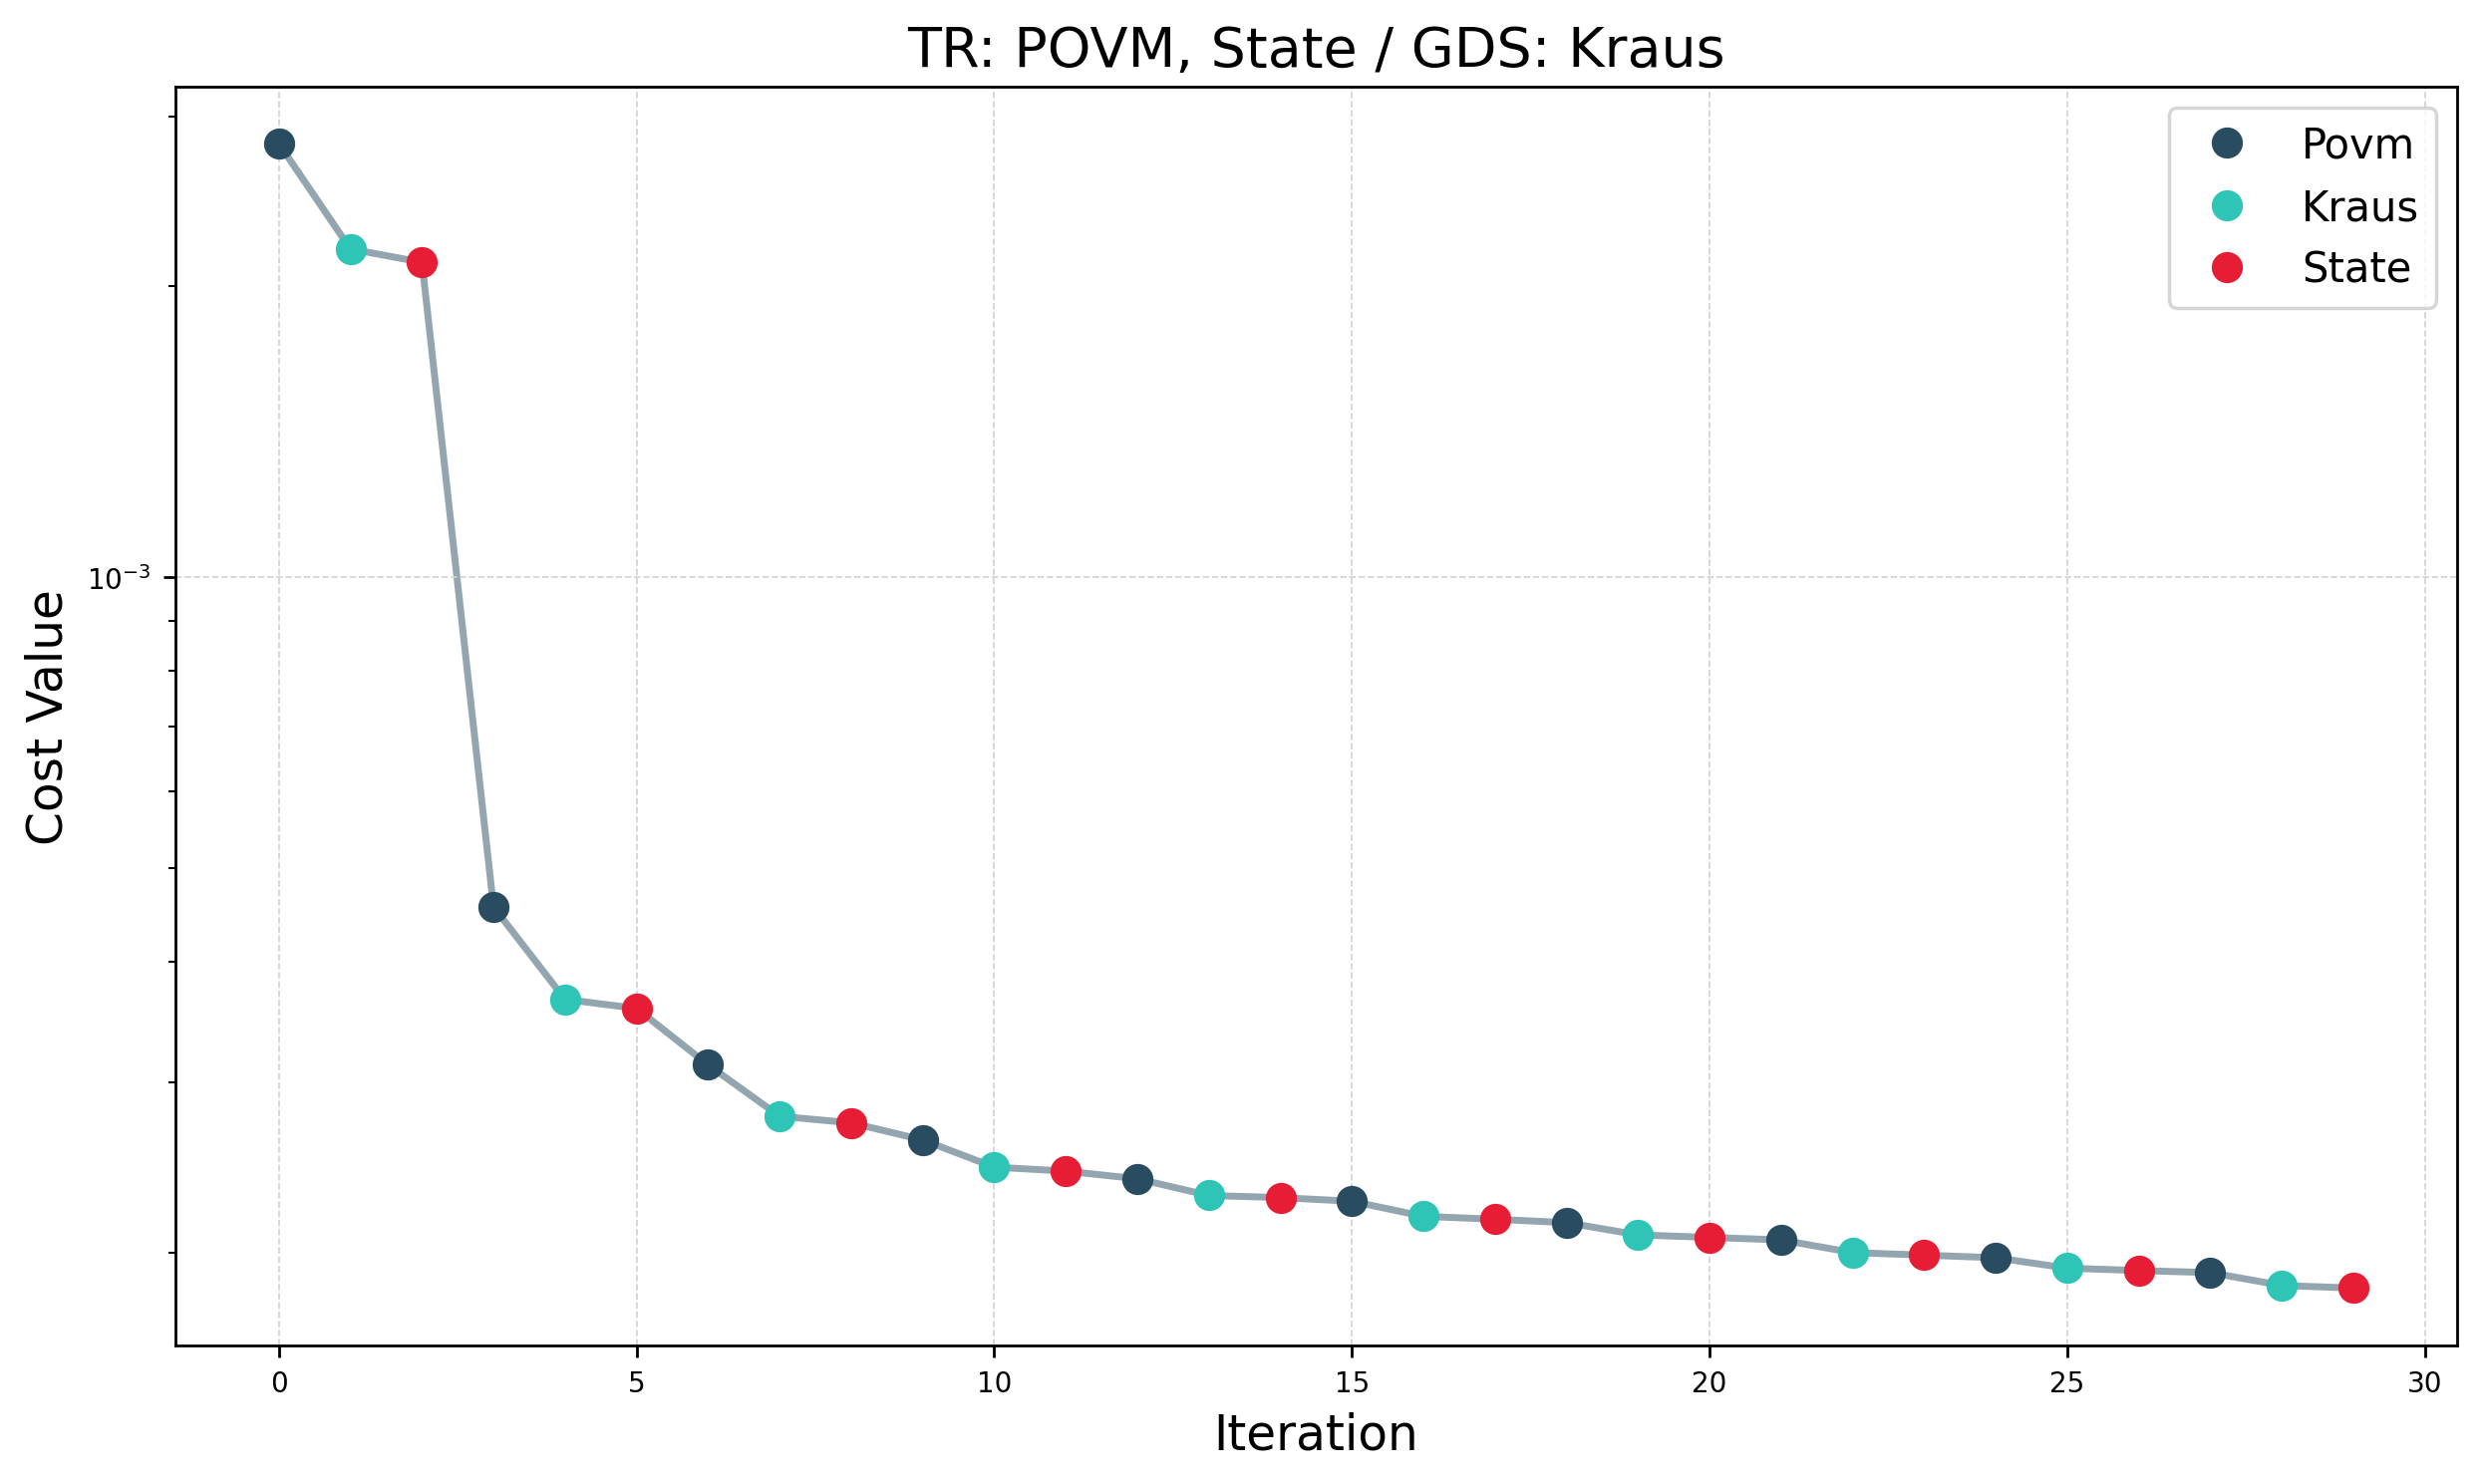

In [64]:
plot_alternating_optimization(cost_fn_history_kraus_gds, title="TR: POVM, State / GDS: Kraus", operator_order=["POVM", "kraus", "state"])